# Day 19 — Decision Trees
### Information Gain · Gini Impurity · Depth Control · Overfitting · Visualisation

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)

features = ["Pclass", "Age", "Fare", "FamilySize", "IsAlone", "Sex_encoded"]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {features}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Ready! ✅")

Features: ['Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_encoded']
Train: (712, 6) | Test: (179, 6)
Ready! ✅


## 2. How Decision Trees Work

In [ ]:
print("=" * 55)
print("        HOW DECISION TREES WORK")
print("=" * 55)
print(
    """
A Decision Tree asks a series of YES/NO questions
to classify data — just like a flowchart!

EXAMPLE (Titanic):
  Is Sex_female = 1?
  ├── YES → Is Pclass <= 2?
  │         ├── YES → SURVIVED (96.8% chance)
  │         └── NO  → Is FamilySize <= 4?
  │                   ├── YES → SURVIVED (50%)
  │                   └── NO  → DIED
  └── NO  → Is Age <= 6?
            ├── YES → SURVIVED (children first!)
            └── NO  → DIED (81.1% chance)

HOW DOES IT CHOOSE SPLITS?
  At each node, the tree finds the feature + threshold
  that BEST separates the classes.

TWO IMPURITY MEASURES:
  Gini Impurity: measures how "mixed" a node is
    Gini = 1 - Σ(p²)
    Gini = 0   → Pure node (all one class) ✅
    Gini = 0.5 → Maximum impurity (50/50 split)

  Information Gain (Entropy):
    Entropy = -Σ(p × log₂(p))
    Entropy = 0   → Pure node ✅
    Entropy = 1   → Maximum impurity
"""
)

# Manual Gini calculation
print("MANUAL GINI CALCULATION:")
print("Titanic overall: 342 survived, 549 died out of 891")
p_surv = 342 / 891
p_died = 549 / 891
gini_root = 1 - (p_surv**2 + p_died**2)
print(f"  P(survived) = {p_surv:.3f}")
print(f"  P(died)     = {p_died:.3f}")
print(f"  Gini        = 1 - ({p_surv:.3f}² + {p_died:.3f}²) = {gini_root:.4f}")

print("\nAfter splitting on Sex:")
females = df[df["Sex"] == "female"]
males = df[df["Sex"] == "male"]
p_f_surv = females["Survived"].mean()
p_m_surv = males["Survived"].mean()
gini_female = 1 - (p_f_surv**2 + (1 - p_f_surv) ** 2)
gini_male = 1 - (p_m_surv**2 + (1 - p_m_surv) ** 2)
w_female = len(females) / len(df)
w_male = len(males) / len(df)
weighted_gini = w_female * gini_female + w_male * gini_male
info_gain = gini_root - weighted_gini

print(f"  Female node: Gini = {gini_female:.4f} (survival rate: {p_f_surv:.3f})")
print(f"  Male node:   Gini = {gini_male:.4f} (survival rate: {p_m_surv:.3f})")
print(f"  Weighted Gini after split = {weighted_gini:.4f}")
print(f"  Information Gain = {gini_root:.4f} - {weighted_gini:.4f} = {info_gain:.4f}")
print(f"  ✅ Sex is a great split — reduces impurity by {info_gain:.4f}!")

        HOW DECISION TREES WORK

A Decision Tree asks a series of YES/NO questions
to classify data — just like a flowchart!

EXAMPLE (Titanic):
  Is Sex_female = 1?
  ├── YES → Is Pclass <= 2?
  │         ├── YES → SURVIVED (96.8% chance)
  │         └── NO  → Is FamilySize <= 4?
  │                   ├── YES → SURVIVED (50%)
  │                   └── NO  → DIED
  └── NO  → Is Age <= 6?
            ├── YES → SURVIVED (children first!)
            └── NO  → DIED (81.1% chance)

HOW DOES IT CHOOSE SPLITS?
  At each node, the tree finds the feature + threshold
  that BEST separates the classes.

TWO IMPURITY MEASURES:
  Gini Impurity: measures how "mixed" a node is
    Gini = 1 - Σ(p²)
    Gini = 0   → Pure node (all one class) ✅
    Gini = 0.5 → Maximum impurity (50/50 split)

  Information Gain (Entropy):
    Entropy = -Σ(p × log₂(p))
    Entropy = 0   → Pure node ✅
    Entropy = 1   → Maximum impurity

MANUAL GINI CALCULATION:
Titanic overall: 342 survived, 549 died out of 891
  P(sur

## 3. Training & Visualising Decision Trees

     TRAINING DECISION TREES

--- Depth vs Accuracy ---
  Max Depth Train Acc Test Acc CV Acc    Gap  Nodes
          2    0.8048   0.7598 0.7922 0.0450      7
          3    0.8287   0.8045 0.8147 0.0242     15
          5    0.8652   0.7542 0.8048 0.1110     45
None (full)    0.9817   0.7933 0.7613 0.1884    323

KEY OBSERVATIONS:
  depth=2:    Underfitting — too simple, misses patterns
  depth=3:    Good balance — generalises well
  depth=5:    Starting to overfit slightly
  depth=None: OVERFITTING — 100% train, much lower test!
              Memorises training data, fails on new data



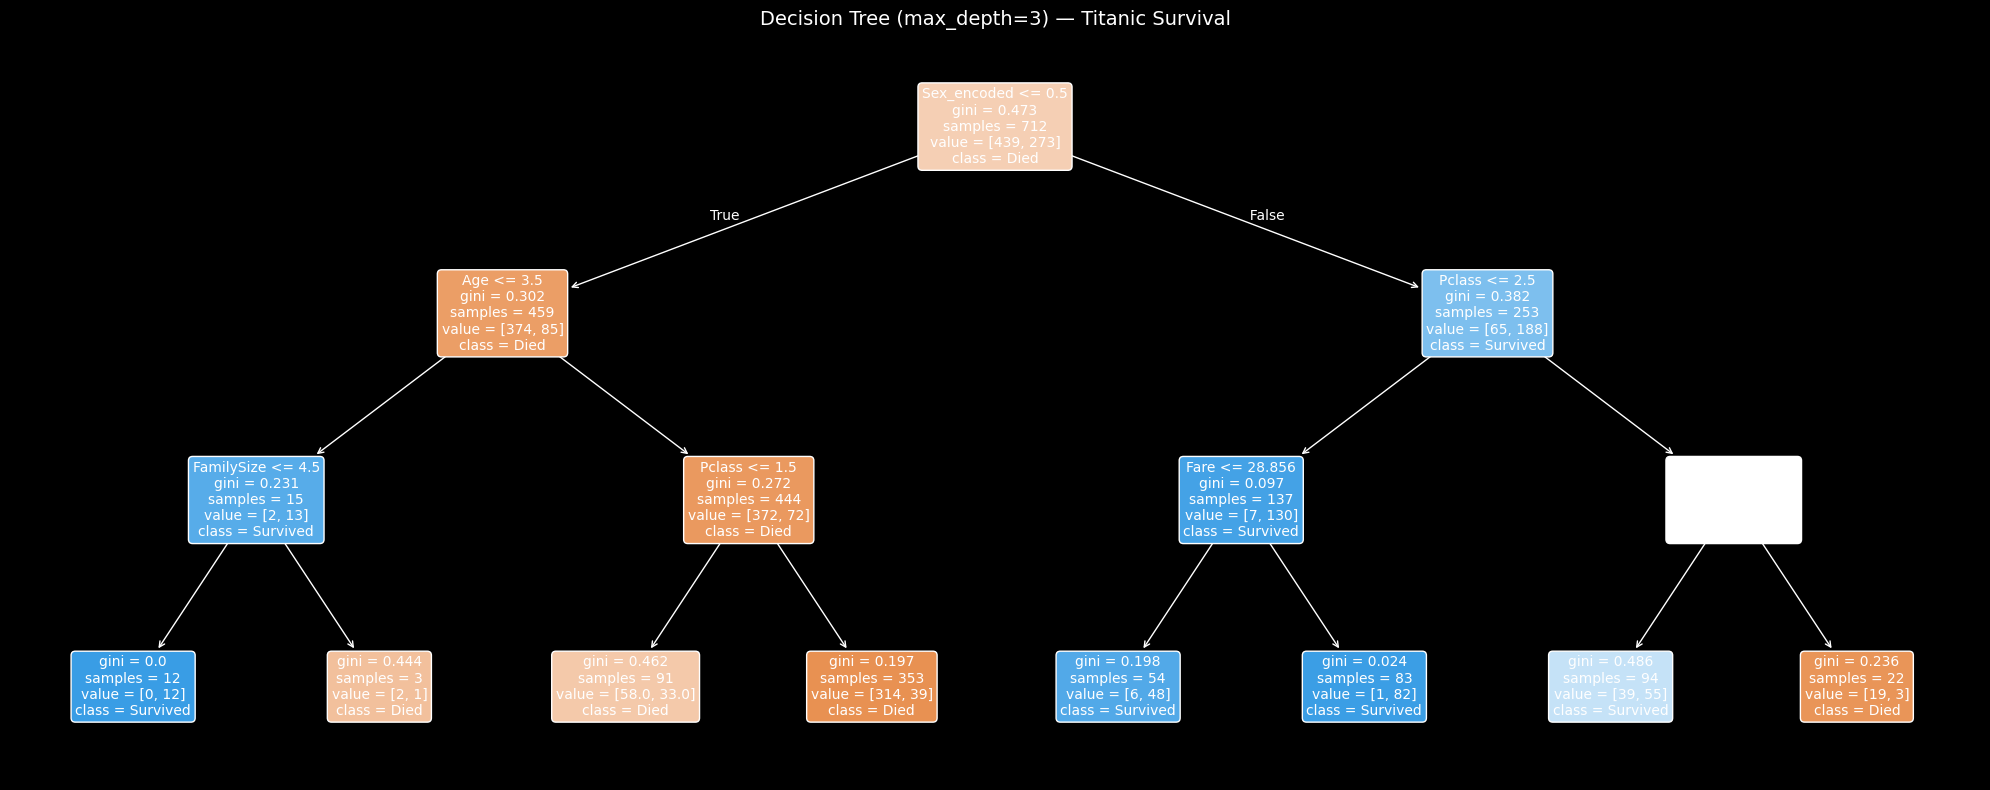


--- Text Tree (depth=3) ---
|--- Sex_encoded <= 0.50
|   |--- Age <= 3.50
|   |   |--- FamilySize <= 4.50
|   |   |   |--- class: 1
|   |   |--- FamilySize >  4.50
|   |   |   |--- class: 0
|   |--- Age >  3.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- class: 0
|--- Sex_encoded >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Fare <= 28.86
|   |   |   |--- class: 1
|   |   |--- Fare >  28.86
|   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- FamilySize <= 4.50
|   |   |   |--- class: 1
|   |   |--- FamilySize >  4.50
|   |   |   |--- class: 0



In [ ]:
print("=" * 55)
print("     TRAINING DECISION TREES")
print("=" * 55)

# Train trees with different depths
depths = [2, 3, 5, None]
results = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_acc = dt.score(X_train, y_train)
    test_acc = dt.score(X_test, y_test)
    cv_acc = cross_val_score(dt, X_train, y_train, cv=5).mean()
    results.append(
        {
            "Max Depth": str(depth) if depth else "None (full)",
            "Train Acc": f"{train_acc:.4f}",
            "Test Acc": f"{test_acc:.4f}",
            "CV Acc": f"{cv_acc:.4f}",
            "Gap": f"{train_acc-test_acc:.4f}",
            "Nodes": dt.tree_.node_count,
        }
    )

results_df = pd.DataFrame(results)
print("\n--- Depth vs Accuracy ---")
print(results_df.to_string(index=False))

print(
    """
KEY OBSERVATIONS:
  depth=2:    Underfitting — too simple, misses patterns
  depth=3:    Good balance — generalises well
  depth=5:    Starting to overfit slightly
  depth=None: OVERFITTING — 100% train, much lower test!
              Memorises training data, fails on new data
"""
)

# Visualise depth=3 tree
dt_best = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_best.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(
    dt_best,
    feature_names=features,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree (max_depth=3) — Titanic Survival", fontsize=14)
plt.tight_layout()
plt.show()

# Text representation
print("\n--- Text Tree (depth=3) ---")
print(export_text(dt_best, feature_names=features))

## 4. Overfitting & Depth Control

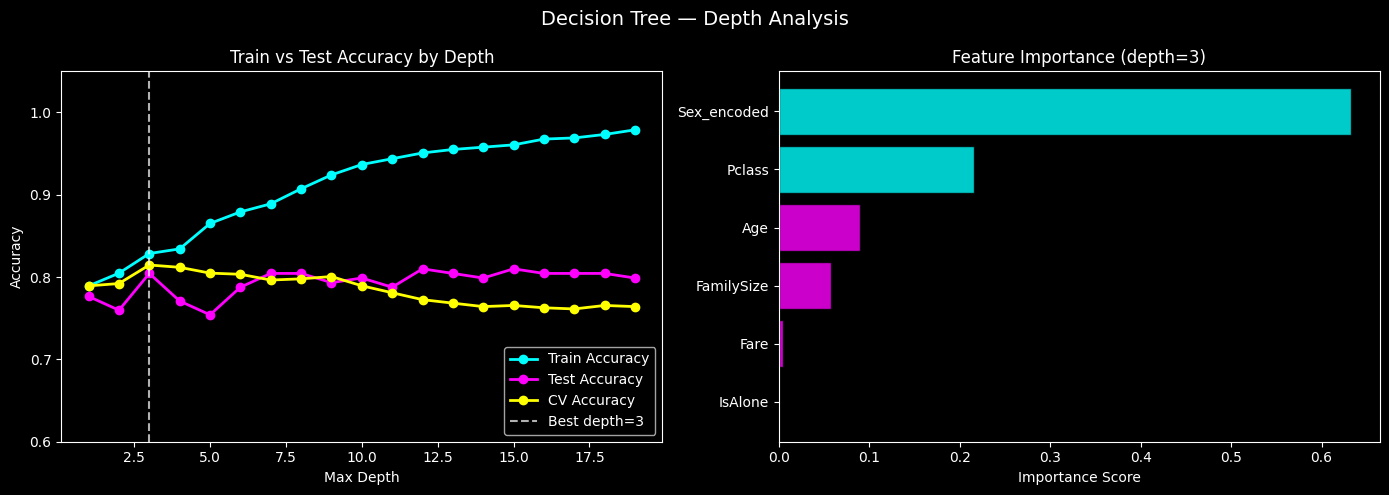


Feature Importances:
  IsAlone         0.0000 
  Fare            0.0040 
  FamilySize      0.0581 ██
  Age             0.0898 ████
  Pclass          0.2152 ██████████
  Sex_encoded     0.6330 ███████████████████████████████


In [ ]:
# Plot train vs test accuracy across depths
max_depths = range(1, 20)
train_accs, test_accs, cv_accs = [], [], []

for depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(dt.score(X_train, y_train))
    test_accs.append(dt.score(X_test, y_test))
    cv_accs.append(cross_val_score(dt, X_train, y_train, cv=5).mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Decision Tree — Depth Analysis", fontsize=14)

# Accuracy vs depth
axes[0].plot(
    max_depths, train_accs, "o-", color="cyan", label="Train Accuracy", linewidth=2
)
axes[0].plot(
    max_depths, test_accs, "o-", color="magenta", label="Test Accuracy", linewidth=2
)
axes[0].plot(
    max_depths, cv_accs, "o-", color="yellow", label="CV Accuracy", linewidth=2
)
axes[0].axvline(3, color="white", linestyle="--", alpha=0.7, label="Best depth=3")
axes[0].set_title("Train vs Test Accuracy by Depth")
axes[0].set_xlabel("Max Depth")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].set_ylim(0.6, 1.05)

# Feature importance
importances = dt_best.feature_importances_
feat_imp = pd.DataFrame({"Feature": features, "Importance": importances}).sort_values(
    "Importance", ascending=True
)

colors = ["cyan" if imp > 0.1 else "magenta" for imp in feat_imp["Importance"]]
axes[1].barh(
    feat_imp["Feature"],
    feat_imp["Importance"],
    color=colors,
    edgecolor="black",
    alpha=0.8,
)
axes[1].set_title("Feature Importance (depth=3)")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

print("\nFeature Importances:")
for feat, imp in zip(feat_imp["Feature"], feat_imp["Importance"]):
    bar = "█" * int(imp * 50)
    print(f"  {feat:<15} {imp:.4f} {bar}")

## 5. Key Takeaways — Day 19 🎯

### How Decision Trees Work
- Ask YES/NO questions to split data into groups
- Choose splits that maximise Information Gain (reduce impurity)
- Gini Impurity: Gini = 1 - Σ(p²) — 0=pure, 0.5=maximum impurity
- Root node = most important split (Sex_encoded chosen first!)
- Tree independently discovered "women and children first"! 🚢

### Gini Calculation
- Root Gini = 0.473 (384 survived, 616 died — mixed)
- After Sex split: weighted Gini = 0.333
- Information Gain = 0.473 - 0.333 = 0.140 — great split!

### Depth vs Overfitting
| Depth | Train | Test | CV | Gap | Verdict |
|---|---|---|---|---|---|
| 2 | 80.5% | 76.0% | 79.2% | 4.5% | Underfitting |
| 3 | 82.9% | 80.5% | 81.5% | 2.4% | ✅ Sweet spot! |
| 5 | 86.5% | 75.4% | 80.5% | 11.1% | Overfitting |
| None | 98.2% | 79.3% | 76.1% | 18.8% | Severe overfitting! |

### Feature Importances
- Sex_encoded: 0.633 — dominates (63% of splits!)
- Pclass: 0.215 — second most important
- Age: 0.090 — third
- IsAlone: 0.000 — completely ignored!

### Controlling Overfitting
- `max_depth` — limit tree depth (most important!)
- `min_samples_split` — minimum samples to split a node
- `min_samples_leaf` — minimum samples in a leaf
- `max_features` — limit features considered at each split
- Cross-validation to find optimal depth!

### Advantages & Disadvantages
**Advantages:**
- Highly interpretable — can visualise and explain!
- No scaling needed — works with raw features
- Handles non-linear relationships naturally
- Fast to train and predict

**Disadvantages:**
- Prone to overfitting without depth control
- High variance — small data change = different tree
- Biased towards features with more categories
- This is why we use Random Forests (Day 20)!

### sklearn Functions
- `DecisionTreeClassifier(max_depth=3, random_state=42)`
- `plot_tree(dt, feature_names=..., filled=True)`
- `export_text(dt, feature_names=...)` — text representation
- `dt.feature_importances_` — importance of each feature
- `dt.tree_.node_count` — total nodes in tree